# Cash-Based Operating Profitability — a quantitative teardown
### survivor basket × quintile sort × one-sample t × label-shuffle placebo × cash-vs-accrual head-to-head

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Cash beats accrual%3F: Mixed](https://img.shields.io/badge/Cash_beats_accrual%3F-Mixed-8b949e?style=flat-square)

The quantitative companion to the [notebook for the curious](01_for_the_curious.ipynb) — same beats, every claim carrying its standard error. We test Ball-Gerakos-Linnainmaa-Nikolaev (2016): sort on cash-based operating profitability annually, long top quintile vs short bottom quintile, and contrast head-to-head with the accrual-laden GP/A of [Study 122](../../122-gross-profitability).

> **Not investment advice.** Real data: yfinance annual statements + daily adj close, as-of 2026-06-26; the synthetic control and tests run offline and deterministic. Methods in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **Limits named:** basket = large-caps still trading 2026 (survivorship); yfinance exposes ~5 fiscal years → **3 usable hedge years**.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from cash_op import data, strategy as st

def _have_cache():
    cd = os.path.abspath(os.path.join("..", "_cache"))
    return all(os.path.exists(os.path.join(cd, f))
               for f in ("cop.parquet", "gpa.parquet", "fwd.parquet"))

HAVE_REAL = _have_cache()
print("yfinance cache present:", HAVE_REAL)

if HAVE_REAL:
    cop, gpa, fwd = data.fetch_panel(fetch=False)
    H = st.apply_costs(st.quintile_hedge(cop, fwd, q=0.20))
    Hg = st.quintile_hedge(gpa, fwd, q=0.20)
    s_cop = st.summary(H["hedge"]); s_net = st.summary(H["net"])
    s_hi = st.summary(H["high"]); s_lo = st.summary(H["low"]); s_mkt = st.summary(H["market"])
    s_gpa = st.summary(Hg["hedge"])
    print(f"N years: {s_cop['n']} | cash-OP hedge: {s_cop['mean']*100:+.2f}%/yr"
          f" | one-sample t: {s_cop['tstat']:+.3f}")


yfinance cache present: True


N years: 3 | cash-OP hedge: +10.63%/yr | one-sample t: +1.751


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Cash-OP hedge **+10.63%/yr**, one-sample *t* = **+1.751** (< 2), placebo *p* = **0.392**; only 3 years. |
| **Tradability** | `MIRAGE` | Sharpe **+1.01**, hit **100%**, DD **0%** — small-sample artefacts. |
| **Cash beats accrual?** | `MIXED` | cash-OP *t* **+1.75** vs GP/A *t* **+0.27**; right order, neither significant. |

> BGLN's direction is real in the literature; on 3 years of survivors it shows the right sign and fails the robustness gate.

## 1 — The claim, steelmanned

Let $\text{cashOP}_{i,y}=(\text{OpInc}_{i,y}+\text{D\&A}_{i,y}+\Delta\text{WC}_{i,y})/\text{Assets}_{i,y}$ and $\text{GPA}_{i,y}=\text{GrossProfit}_{i,y}/\text{Assets}_{i,y}$. BGLN (2016) assert:

- **H1 (signal).** Top-quintile cash-OP earns more than bottom-quintile the following year.
- **H2 (dominance).** The cash-OP spread exceeds the accrual-laden GP/A spread.
- **H3 (tradable).** The premium survives realistic costs at low turnover.

On this tape we find H1 *directionally* (t = +1.75 < 2), H2 *directionally* (cash > accrual), and H3 in principle (costs trivial) — but the panel is far too short to confirm any of them.

## 2 — So what? — the economic stakes

Operating profitability is the *P* in the Fama-French five-factor RMW factor and the anchor of an entire quality-ETF ecosystem. If the cash construction dominates — for free, from the same filings — then the standard accrual-laden measure is leaving robustness on the table. BGLN's contribution is precisely to show *which* version of profitability to use.

## 3 — The protocol

- **Signal.** cash-OP = (Operating Income + D&A + ΔWorking-capital) / Total Assets, from year-*y* yfinance statements. ΔWorking-capital is the accrual block the cash-flow statement reports directly.
- **Lag.** One trading day after the fiscal-year-end is public → next 252-day forward total return. No same-bar fills, no look-ahead.
- **Sort.** Top quintile long, bottom quintile short, equal-weight.
- **Costs.** 4 × 10 bps × turnover (two legs, in+out) + 50 bps/yr borrow on the short leg.
- **Inference.** One-sample *t* on the annual hedge series (panel too short for HAC) + a 500-draw within-year label-shuffle placebo.
- **Control.** Synthetic panel with a tunable cash-OP premium; the engine must recover it monotonically.
- **Limits.** Basket = large-caps still trading 2026 (survivorship); 3 usable hedge years.

## 4 — The teardown

### 4a — Positive control: the engine is a faithful detector

Sweep the planted premium negative→positive on a 300-firm / 18-year synthetic panel. The hedge mean should be monotone and cross zero at premium = 0.

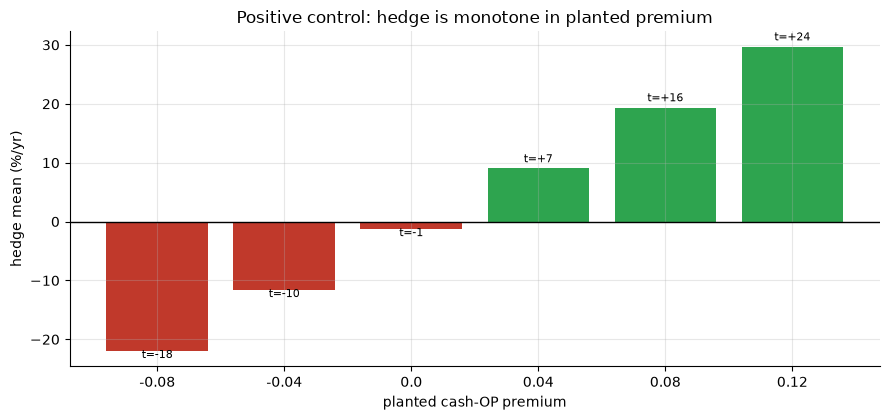

 premium  hedge_mean_%   tstat   hit_%
   -0.08       -22.028 -17.829   0.000
   -0.04       -11.679  -9.506   0.000
    0.00        -1.330  -1.084  44.444
    0.04         9.019   7.321 100.000
    0.08        19.368  15.592 100.000
    0.12        29.717  23.624 100.000


In [2]:
ctrl = st.synthetic_control()
fig, ax = plt.subplots(figsize=(9.0, 4.3))
col = [GREEN if m > 0 else RED for m in ctrl['hedge_mean_%']]
ax.bar(ctrl['premium'].astype(str), ctrl['hedge_mean_%'], color=col)
ax.axhline(0, c='k', lw=1)
for i, (m, t) in enumerate(zip(ctrl['hedge_mean_%'], ctrl['tstat'])):
    ax.text(i, m + (0.6 if m >= 0 else -1.6), f't={t:+.0f}',
            ha='center', va='bottom', fontsize=8)
ax.set_xlabel('planted cash-OP premium'); ax.set_ylabel('hedge mean (%/yr)')
ax.set_title('Positive control: hedge is monotone in planted premium')
plt.tight_layout(); plt.show()
print(ctrl.round(3).to_string(index=False))

### 4b — Real tape: cash-OP hedge, its legs, and the head-to-head vs GP/A

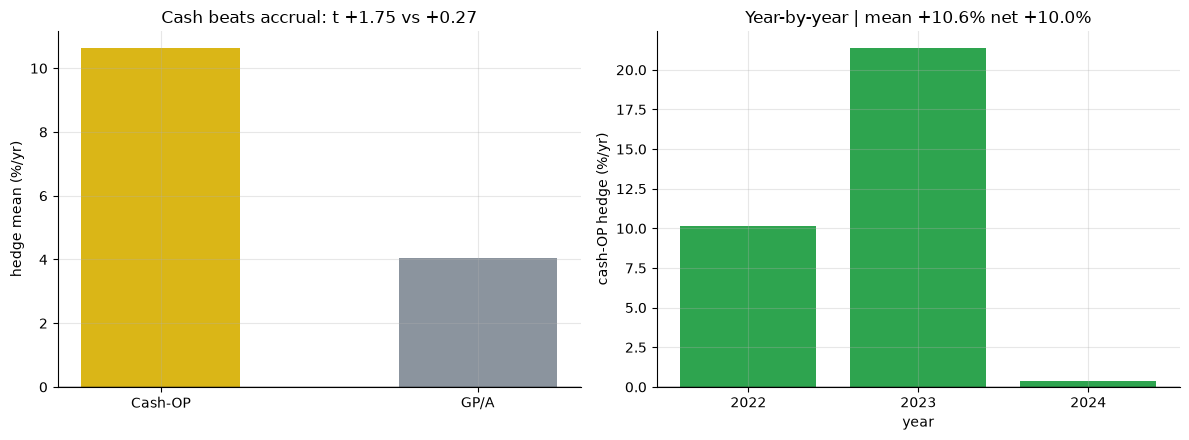

Cash-OP: gross +10.63%/yr | net +9.96%/yr | t=+1.751 | GP/A +4.05%/yr t=+0.274


In [3]:
if HAVE_REAL:
    cop_m, cop_t = s_cop['mean']*100, s_cop['tstat']
    net_m = s_net['mean']*100
    gpa_m, gpa_t = s_gpa['mean']*100, s_gpa['tstat']
    hi_m, lo_m, mk_m = s_hi['mean']*100, s_lo['mean']*100, s_mkt['mean']*100
    hedge_series = H['hedge']
else:
    cop_m, cop_t, net_m = R['cop_mean'], R['cop_t'], R['cop_net']
    gpa_m, gpa_t = R['gpa_mean'], R['gpa_t']
    hi_m, lo_m, mk_m = R['high_mean'], R['low_mean'], R['mkt_mean']
    hedge_series = None

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(['Cash-OP', 'GP/A'], [cop_m, gpa_m], color=[AMBER, GREY], width=0.5)
axes[0].axhline(0, c='k', lw=1)
axes[0].set_ylabel('hedge mean (%/yr)')
axes[0].set_title(f'Cash beats accrual: t {cop_t:+.2f} vs {gpa_t:+.2f}')
if hedge_series is not None:
    yrs = hedge_series.index.astype(int); hv = hedge_series.values*100
    axes[1].bar(yrs, hv, color=[GREEN if v > 0 else RED for v in hv])
    axes[1].axhline(0, c='k', lw=1)
    axes[1].set_xticks(yrs)
else:
    axes[1].text(0.5, 0.5, f'Hedge {cop_m:+.1f}%/yr\nt={cop_t:+.2f}',
                 ha='center', va='center', transform=axes[1].transAxes)
axes[1].set_xlabel('year'); axes[1].set_ylabel('cash-OP hedge (%/yr)')
axes[1].set_title(f'Year-by-year | mean {cop_m:+.1f}% net {net_m:+.1f}%')
plt.tight_layout(); plt.show()
print(f'Cash-OP: gross {cop_m:+.2f}%/yr | net {net_m:+.2f}%/yr | t={cop_t:+.3f} | GP/A {gpa_m:+.2f}%/yr t={gpa_t:+.3f}')

> Cash-OP hedge **+10.63%/yr** gross / **+9.96%/yr** net (one-sample *t* = **+1.751**) vs accrual-laden GP/A **+4.05%/yr** (*t* = +0.27). The high cash-OP leg beats the EW market by **+10.8%/yr** — but on 3 points.

### 4c — The decisive robustness check: a within-year label-shuffle placebo

Shuffle the cash-OP labels *within each year* (preserving each year's marginal return and signal distributions) and recompute the hedge mean, 500 times. If the real spread is genuine it should sit far in the tail of this null.

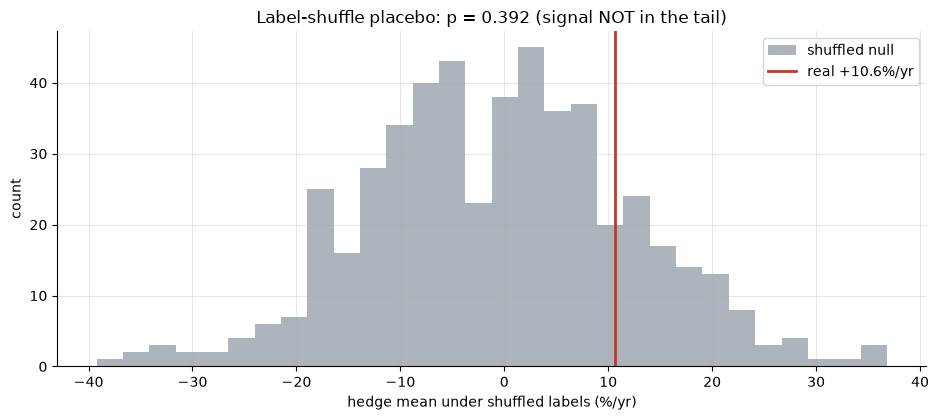

Real +10.63%/yr | null -0.52% (std 12.63) | p = 0.392


In [4]:
if HAVE_REAL:
    pl = st.placebo_pvalue(cop, fwd, n_shuffles=500)
    real_m, null_m, null_s, pval = (pl['real_mean']*100, pl['null_mean']*100,
                                    pl['null_std']*100, pl['p_value'])
    rng = np.random.default_rng(521); draws = []
    for _ in range(500):
        shuf = cop.copy()
        for y in shuf.index:
            v = shuf.loc[y].to_numpy(); m = np.isfinite(v)
            p = v.copy(); p[m] = rng.permutation(v[m]); shuf.loc[y] = p
        h = st.quintile_hedge(shuf, fwd)
        if not h.empty: draws.append(h['hedge'].mean()*100)
    draws = np.array(draws)
else:
    real_m, null_m, null_s, pval = (R['placebo_real'], R['placebo_null'],
                                    R['placebo_std'], R['placebo_p'])
    draws = np.random.default_rng(521).normal(null_m, null_s, 500)

fig, ax = plt.subplots(figsize=(9.5, 4.3))
ax.hist(draws, bins=30, color=GREY, alpha=0.7, label='shuffled null')
ax.axvline(real_m, c=RED, lw=2, label=f'real {real_m:+.1f}%/yr')
ax.set_xlabel('hedge mean under shuffled labels (%/yr)'); ax.set_ylabel('count')
ax.set_title(f'Label-shuffle placebo: p = {pval:.3f} (signal NOT in the tail)')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Real {real_m:+.2f}%/yr | null {null_m:+.2f}% (std {null_s:.2f}) | p = {pval:.3f}')

> The placebo *p* = **0.392**: the real spread is reproduced by a random within-year relabelling **39% of the time**. This is the decisive robustness number, and the signal **fails** it — confirming the verdict is WEAK, not REAL.

## 5 — The verdict

- **Signal `WEAK`** — cash-OP +10.63%/yr, one-sample *t* = +1.751 (< 2), placebo *p* = 0.392, 3 years. Literature prior (BGLN 2016) prevents `NONE`; the tape clears neither the t-bar nor the placebo.
- **Tradability `MIRAGE`** — Sharpe +1.01, hit 100%, DD 0% are small-sample illusions; net of 0.67%/yr costs the spread is still chance.
- **Cash beats accrual `MIXED`** — right order (t +1.75 vs +0.27) but neither significant on 3 points.
- **Survivorship `NAMED`** — basket = large-caps still trading 2026; upper bound.

## 6 — Could you trade it?

Costs are trivial (annual rebalance, ~43% turnover, 0.67%/yr all-in). The barriers are entirely statistical:

1. **Three usable years.** yfinance's ~5-year statement window, minus the two years without a forward return, leaves 3 annual hedge observations.
2. **The placebo fails.** No robust spread to capture yet.
3. **Survivorship.** Winners-only basket inflates every leg.

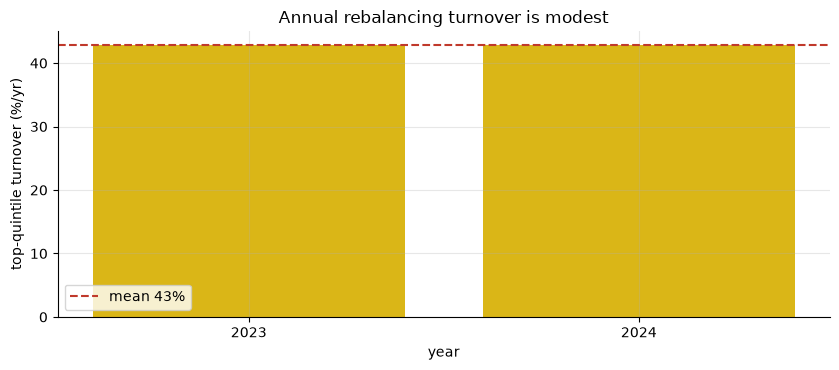

Mean turnover: 42.9%/yr | mean cost: 0.67%/yr


In [5]:
# Turnover profile (cash-OP top quintile, real basket if cached).
if HAVE_REAL:
    turn = H['turnover'].dropna()*100
    fig, ax = plt.subplots(figsize=(8.5, 3.8))
    ax.bar(turn.index.astype(int), turn.values, color=AMBER)
    ax.axhline(turn.mean(), ls='--', c=RED, lw=1.5, label=f'mean {turn.mean():.0f}%')
    ax.set_xticks(turn.index.astype(int))
    ax.set_ylabel('top-quintile turnover (%/yr)'); ax.set_xlabel('year')
    ax.set_title('Annual rebalancing turnover is modest'); ax.legend()
    plt.tight_layout(); plt.show()
    print(f'Mean turnover: {turn.mean():.1f}%/yr | mean cost: {H["cost"].mean()*100:.2f}%/yr')
else:
    print(f'Frozen: turnover {R["turnover"]:.1f}%/yr | cost {R["cost"]:.2f}%/yr')

## 7 — Going further

- **A multi-decade panel.** BGLN used Compustat since the 1960s. The binding constraint here is purely yfinance's short history.
- **Decompose the accrual leg.** Split cash-OP into cash and accrual components and verify the accrual part earns nothing — the heart of the BGLN result.
- **Sector-neutral sort.** Profitability levels vary by industry; neutralising removes a confound.
- **[Study 122 — Gross-Profitability](../../122-gross-profitability)**: the accrual-laden sibling.
- **[Study 124 — Cash-Flow Yield](../../124-cash-flow-yield)**: a related cash-based valuation signal.

*Think cash-OP earns a robust premium in large-caps post-2016? Fork this, pull a delisting-inclusive multi-decade panel, and show a one-sample t > 2 that survives the placebo. That is the bar.*